### Deliverable 1: Description and Initial Data Analysis

## 1. Data Acquisition and Cleaning

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["WALMEX.MX", "AC.MX", "FEMSAUBD.MX", "BIMBOA.MX", "ALSEA.MX", "AAPL", "MSFT", "AMZN", "KO", "PG"]

start_date = "2021-08-31"
end_date = "2026-08-31"

raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]

[*********************100%***********************]  10 of 10 completed


First,we selected 10 stocks, 5 Mexican and 5 US stocks, because the firm invests in stocks both from Mexico and the US. We obtained their historical information through the API yfinance.
Something important to highlight is that the data is the adjusted closing prices, as some stocks pay dividends.
Through the function head(),  we observe the first 5 rows of values from. the stocks closing prices.

In [3]:
print(raw_data.shape)
print(raw_data.isna().sum())

(1293, 10)
Ticker
AAPL           39
AC.MX          37
ALSEA.MX       37
AMZN           39
BIMBOA.MX      37
FEMSAUBD.MX    37
KO             39
MSFT           39
PG             39
WALMEX.MX      37
dtype: int64


Through the function .shape(), we can observe that the shape of the dataset is 1293 rows and the 10 columns of the stocks. On the. other side, through the function .isna().sum(), we can. notice thatthere. aremany. missing values in all the columns, so we need to fix it.

In [4]:
fondo = raw_data.ffill().dropna()
fondo.index = pd.to_datetime(fondo.index)
fondo.to_csv("fondo.csv")

print("Saved fondo.csv with shape:", fondo.shape)
print(fondo.isna().sum())

Saved fondo.csv with shape: (1293, 10)
Ticker
AAPL           0
AC.MX          0
ALSEA.MX       0
AMZN           0
BIMBOA.MX      0
FEMSAUBD.MX    0
KO             0
MSFT           0
PG             0
WALMEX.MX      0
dtype: int64


Trough the function .ffill(), the code replaces each NaN with the last known value for that column, we decided to do this to maintain the most recent available market price when a stock did not trade on a particular date.
Trough the function .dropna(), the code removes rows that are still NaN after ffill.
We also converted the data set into a cvs file named fondo, so we could have the data clean and ready to use.

## 2. Identification of Dependent and Independent Variables

In [5]:
returns = fondo.pct_change().dropna()
returns.to_csv("returns.csv")

fondo_return = returns.mean(axis=1)
fondo_return.name = "Fondo_Return"
fondo_index = (1 + fondo_return).cumprod()

With the function .pct_change(), we are able to convert the daily prices into daily percentage returns. In addition, through .mean(axis=1), we get the daily average of returns of the portfolio, with the assumption that all the stocks have equal weights.
### Dependent variable: fondo_return, or the equal-weighted daily return of the 10 stock portfolio

In [6]:
tech = pd.DataFrame(index=fondo_return.index)
tech["Lag_Return"] = fondo_return.shift(1)
tech["SMA_50"] = fondo_index.rolling(window=50).mean().shift(1)
tech["SMA_200"] = fondo_index.rolling(window=200).mean().shift(1)

delta = fondo_index.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
tech["RSI_14"] = (100 - (100 / (1 + rs))).shift(1)

print(tech.isna().sum())
tech.tail()

Lag_Return      1
SMA_50         50
SMA_200       200
RSI_14         14
dtype: int64


,Lag_Return,SMA_50,SMA_200,RSI_14
Date,,,,
2026-08-24,0.005293,1.590013,1.564452,34.368898
2026-08-25,0.009048,1.590510,1.564830,40.246843
2026-08-26,0.005511,1.591126,1.565351,48.005964
2026-08-27,-0.001267,1.592012,1.565869,45.764691
2026-08-28,-0.006869,1.592836,1.566369,38.967624


Through .shift(1), we built an initial independent variable, we moved every value ofthe portfolio or fund returns down one row, so now any given date shows yesterdays return. In order to use information that already existed to predict the next day.

After that, we leverage code to build the SMA 50 and SMA200 indicators, as well as the RSI, some technical indicators that we will leverage as independent variables.
Then we were able to visualize a few rows of our data fram with the values of the returns and indicators.

After checking for missing values, we can check that for SMA 50, there are 50 missing values, as ypu need the intial 50 values to calculate it, for SMA 200, 200 missing values and for RSI 14, all because of the same logic.

In [7]:
macro_tickers = ["^GSPC", "^MXX", "^TNX"]  # S&P 500, IPC (Mexico), 10-Year Treasury Yield
macro_data = yf.download(macro_tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
macro_data = macro_data.ffill().dropna()

macro_returns = macro_data.copy()
macro_returns["^GSPC"] = macro_returns["^GSPC"].pct_change()
macro_returns["^MXX"] = macro_returns["^MXX"].pct_change()
macro_returns["^TNX"] = macro_returns["^TNX"].diff()
macro_returns = macro_returns.dropna()
macro_returns.columns = ["SP500_return", "IPC_return", "Treasury10Y_change"]
macro_returns_lagged = macro_returns.shift(1)
macro_returns_lagged.columns = [c + "_lag1" for c in macro_returns_lagged.columns]

macro_returns_lagged.head()

[*********************100%***********************]  3 of 3 completed


,SP500_return_lag1,IPC_return_lag1,Treasury10Y_change_lag1
Date,,,
2021-09-01,NaN,NaN,NaN
2021-09-02,0.000312,-0.020433,-0.002
2021-09-03,0.002843,-0.002453,-0.008
2021-09-06,-0.000335,-0.004845,0.028
2021-09-07,0.000000,0.008643,0.000


As some other independent variables we decided to use the S&P500, the IPC and the index that. reflects the returns of the 10 year US treasury bond.
In consequence, we also extract this information leveraging yahoo finance, applying thesame cleaning logic as before with the stocks,  and creating a data frame of macroeconomic independent variables. 

In [7]:
model_data = pd.concat([fondo_return, tech, macro_returns_lagged], axis=1).dropna()
model_data.to_csv("model_data.csv")

print(model_data.shape)
model_data.head()

(1092, 8)


,Fondo_Return,Lag_Return,SMA_50,SMA_200,RSI_14,SP500_return_lag1,IPC_return_lag1,Treasury10Y_change_lag1
Date,,,,,,,,
2022-06-09,-0.014594,-0.002137,1.040299,1.041474,70.001382,-0.010794,-0.006380,0.019179
2022-06-10,-0.026106,-0.014594,1.038114,1.041468,58.650131,-0.023799,-0.010620,0.004952
2022-06-13,-0.018568,-0.026106,1.035361,1.041328,41.596266,-0.029110,-0.016610,0.036794
2022-06-14,-0.010321,-0.018568,1.032109,1.041124,37.661769,-0.038768,-0.000541,0.066540
2022-06-15,0.019167,-0.010321,1.028616,1.040834,31.211206,-0.003774,-0.005797,0.034759


At the end,  we. merged all our columns,  our dependent variables (return of our portfolio created), and the independent variables (technical indicators, as well as macroeconomic variables), here is the justification to use. each of them:
# Dependent variable (Portfolio/Fondo return):
Represents the actual outcome of the client´s investment, the logical variable to be the dependent, as the purpose of the type of analysis performed by the firm is to support portfolio decision making.
## Independent variables
# 1. Lag_Return (technical):
Representing the portfolio´s own return from the previous day, in order to test the weak-form Efficient Market Hypothesis (EMH) and momentum/mean-reversion, which examine if past returns carry any information about future returns.
# 2. SMA_50 and SMA 200 (technical):
Two moving averages of the value of the portfolio, calculated for 50 and 200 days, in order to detect medium and long term trend shifts, for example, the crossovers between the two (known as a "golden cross" or "death cross"). Using this as a long-term indicator can be useful to address the investor's long-term objectives.
# 3. RSI_14 (technical):
A 14 days relative strength index, in order to detect momentum of if the stock is overbought (>70) or oversold (<30), complementing the other technical indicator.
# 4. SP500_return_lag1 (macro):
The prior-day return of the S&P 500 index. Justifies as the CAPM theory explains how a portfolio's return is partly explained by its exposure to broad market movements (due to systematic risk). This is relevant for our portfolio as we included 5 stocks from the US market (AAPL, MSFT, AMZN, KO, PG).
# 5. IPC_return_lag1 (macro):
This is a macro fundamental relevant indicator, as we selected 5 stocks from the mexican market, (WALMEX, AC, FEMSA, BIMBO, ALSEA), all of which trade on the Bolsa Mexicana de Valores.
# 6. Treasury10Y_change_lag1 (macro):
The prior-day change in the 10Y Treasury Bond Yield, as stocks can also be affected by interest rates changes, as changes in the discount rate, changes the discounted value of the companies, this can be relevant and impact the value of the stock for growth-oriented holdings like AMZN or MSFT.


All the independent variables were lagged 1 trading day, to only use information realistically available before predicting the return of our portfolio.





## 3. Evaluation of Information Technologies
For the development of this element, we decided to use Python through GitHub to store the code, as we thought, is a convenient and adequate tool for this situation. First, Python allows us to download directly the information leveraging the Yahoo Finance API, as well as create the data frames and data set files. In addition, it allows us to handle a lot of data information easily and automate the repetitive workflows; it allows us to capture every step in a code block and go back and change details if needed, which is better for traceability. Furthermore, it can be connected directly with advanced machine learning and statistical libraries, which opens further possibilities. It is a better tool for this specific situation compared to manual tools like Excel, which has a max. rows capacity (1,048,576 rows). Even if in this exercise we did not exceed it, it's valuable to consider for other projects. Also, in Excel you need to perform almost every step manually, which can bring human errors; it is more difficult to go back to a specific step; and it has a more clear limit of functionalities.  That is why we selected Python.

## Part 4: Client Risk Profile

In [8]:
import numpy as np

# Annualized volatility of the portfolio
annual_vol = fondo_return.std() * np.sqrt(252)
print(f"Annualized portfolio volatility: {annual_vol:.2%}")

# Annualized volatility per stock, for comparison
stock_vol = returns.std() * np.sqrt(252)
print(stock_vol.sort_values(ascending=False))

Annualized portfolio volatility: 13.23%
Ticker
AMZN           0.358888
BIMBOA.MX      0.310714
ALSEA.MX       0.295684
MSFT           0.277314
AAPL           0.276101
WALMEX.MX      0.250219
FEMSAUBD.MX    0.230372
AC.MX          0.226997
PG             0.178537
KO             0.164436
dtype: float64


Then, to define the clients risk profile, we used the std of the daily returns, in order to measure the volatility of each stock and the portfolio overall. While we can see that AMZN or BIMBOA have volatilities around the .30s, the overall portfolio volatility is around 13.23%, reflecting somehow diversification and a moderate risk profile. In. this context, we created a profile for our excersise client:
Name: Geroge Torres
Age: 41
Ocupation: Mid-level manager at a manufacturing company with stable salaried income.
Investment horizon: Long-term (10+ years), saving for retirement
Investment experience: Moderate, has invested with the help of other funds before, but never by himself.
Risk tolerance: Moderate, willing to accept moderate fluctuations in the portfolio value,  in exchange for long-term growth, but is not comfortable with huge losses.
Primary objective: Capital appreciation with manageable risk.

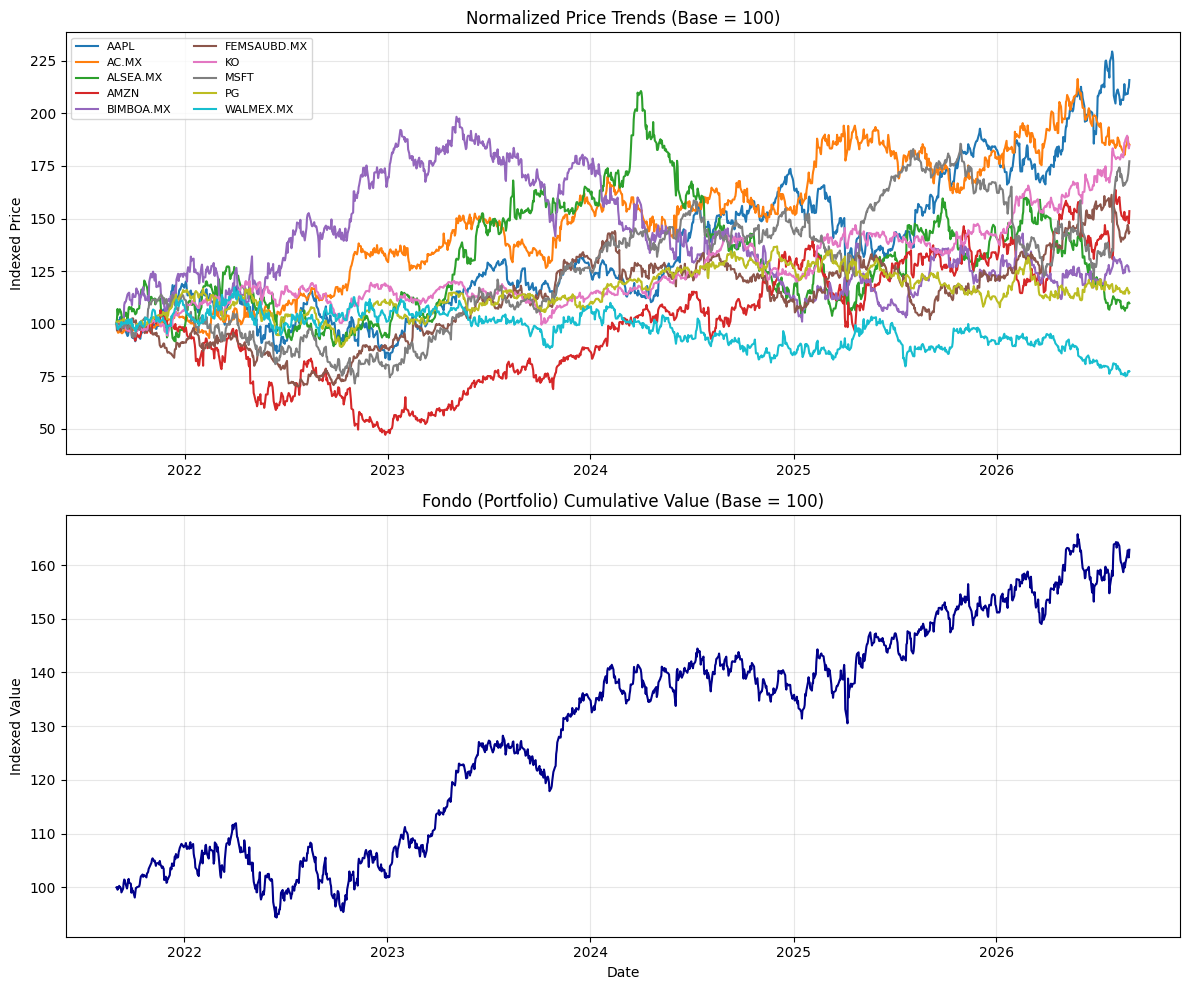

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: individual stocks
normalized_prices = fondo / fondo.iloc[0] * 100
for col in normalized_prices.columns:
    axes[0].plot(normalized_prices.index, normalized_prices[col], label=col)
axes[0].set_title("Normalized Price Trends (Base = 100)")
axes[0].set_ylabel("Indexed Price")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

# Bottom: portfolio (fondo)
fondo_index_series = (1 + fondo_return).cumprod() * 100
axes[1].plot(fondo_index_series.index, fondo_index_series, color="darkblue")
axes[1].set_title("Fondo (Portfolio) Cumulative Value (Base = 100)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Indexed Value")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

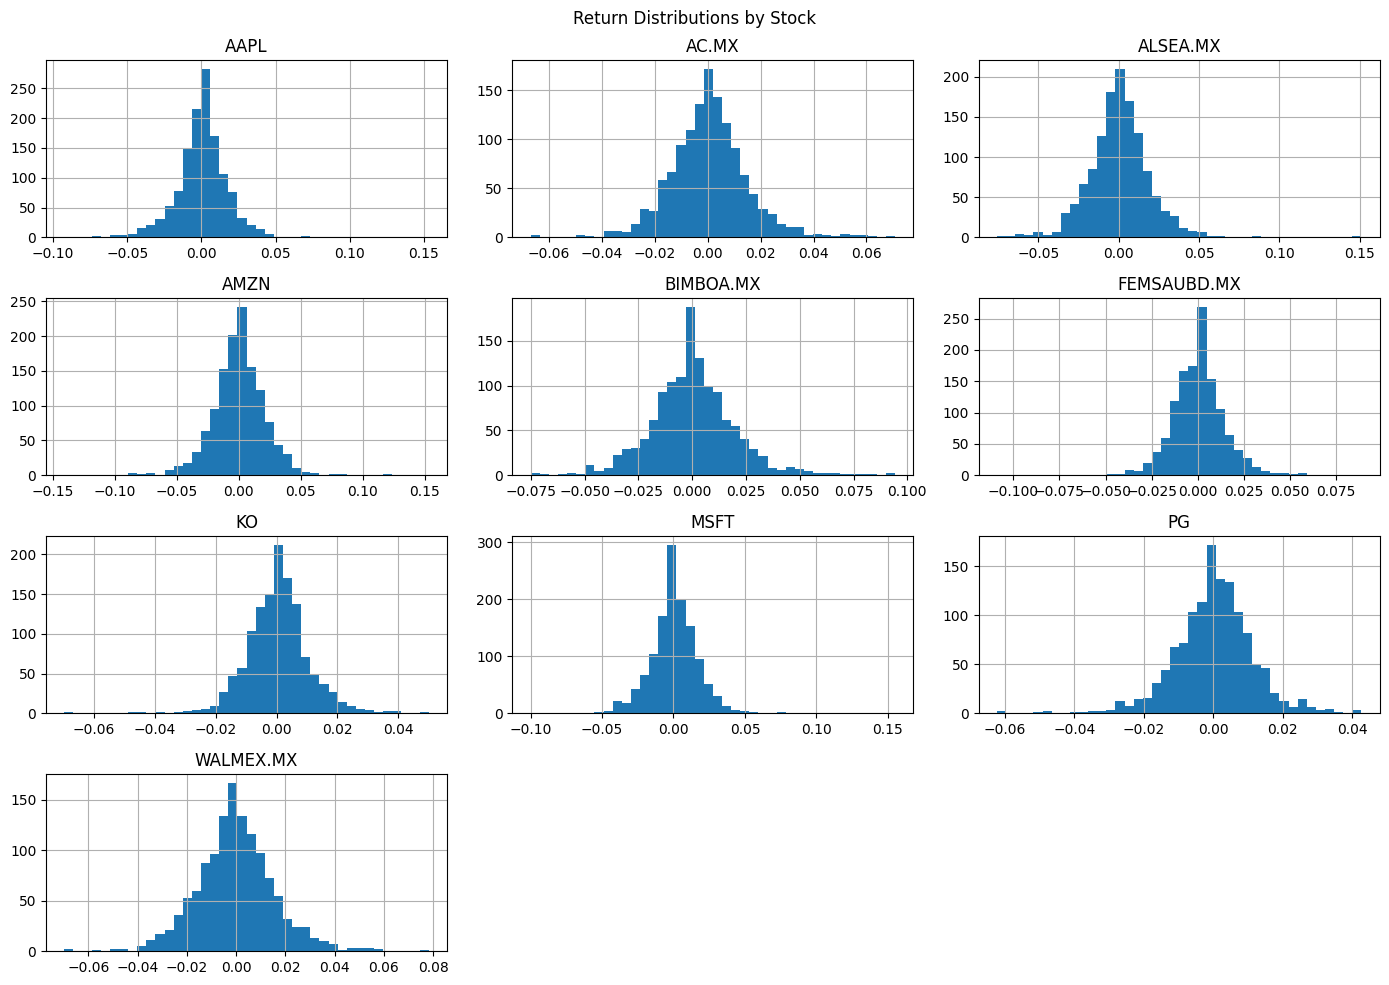

In [10]:
returns.hist(figsize=(14, 10), bins=40)
plt.suptitle("Return Distributions by Stock")
plt.tight_layout()
plt.show()

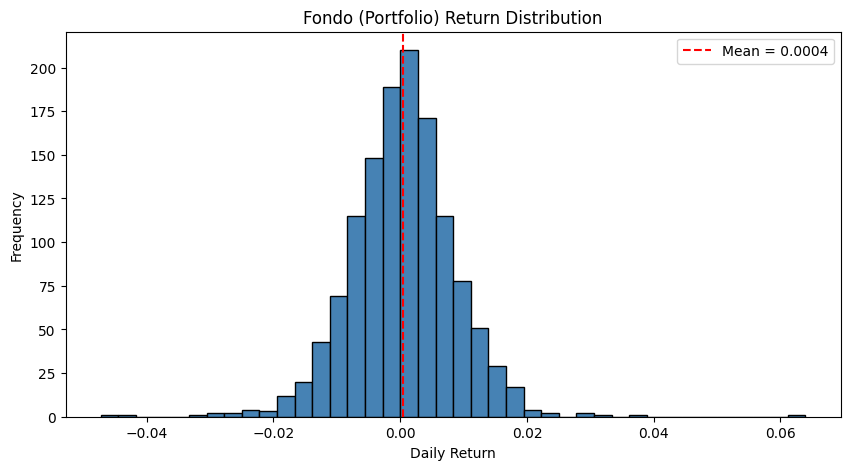

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(fondo_return, bins=40, color="steelblue", edgecolor="black")
plt.axvline(fondo_return.mean(), color="red", linestyle="--", label=f"Mean = {fondo_return.mean():.4f}")
plt.title("Fondo (Portfolio) Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()